### Проектная работа "Прогноз движения отношения валютных пар на рынке Forex через решение задачи классификации"

#### Постановка задачи

На основании комбинации из N свечей предсказать класс целевой свечи N+1.
Возможные классы:
1. Класс покупки (BUY)
2. Класс продажи (SELL)
0. Класс пропуска дейсвтия (PASS)

В результате чего предстоит решение задачи многоклассовой классификации.

Параметры задачи были определены следющими:
- Свеча - характеристики цены по валютной паре за некий период такие как:
    - open - цена открытия на начало периода
    - high - наибольшее значение цены за период
    - low - наименьшее значение цены за период
    - close - цена закрытия на конец периода
- Период свечи выбран равным 12 часам
- N - число свечей в комбинации выбран равным 5, таким образом требуется предсказать класс целевой 6-ой свечи
- Дополнительно до предобработки и целевых вычислений были построены 3 простые средние (SMA) по характеристики цены закрытия за M предшествующих свечей - 5, 10 и 15

Пример такой комбинации:

![example](./example_combination.jpeg)

#### Источник первичных данных

Первоначальные данные несколько лет назад были получены из источника исторических данных брокера [ForexClub](https://www.fxclub.org/), конкретно:
- хост hist-ru-prim.fxclub.org (hist-ru-sec.fxclub.org)
- порт 2022
- протокол проприоритарный
Но по соостоянию на 23.03.2026 данный источник не отвечает.

В вычислениях данной проектной работы использую накопленные данные за период с 2000-01-02 21:00:00 по 2021-06-04 01:00:00 по валютным парам со следующими кодоввыми обозначениями:
- AUD
- CAD
- CHF
- EUR
- GBP
- JPY
- NZD

Собранные первичные данные разместил в РСУБД SQLite в целях использования более привычного инструмента манипулирования данными.

#### Разметка данных

Разметка классов была выполнена автоматически.
- Комбинация помечается классом 1, когда:
    1. Цена закрытия целевой свечи больше, чем её цена открытия.
    2. Тело целевой свечи больше 10% от общего размера свечи.
    3. Цена закрытия последней свечи комбинации больше, чем её цена открытия.
    4. Тело последней свечи комбинации свечи больше 20% от общего размера свечи.
- Комбинация помечается классом 2, когда:
    1. Цена закрытия целевой свечи меньше, чем её цена открытия.
    2. Тело целевой свечи больше 10% от общего размера свечи.
    3. Цена закрытия последней свечи комбинации меньше, чем её цена открытия.
    4. Тело последней свечи комбинации свечи больше 20% от общего размера свечи.
- В иных случая комбинация помечается классом 0.

#### Признаки комбинации
Для каждой свечи в комбинации выводятся следующие признаки:
1. Все абсолютные ценовые характеристики (open, high, low, close), включая показатели МА (ma5, ma10, ma15) масштабируются к размеру [0,1] в пределах комбинации.
2. Из даты свечи (dtime) выделяется день недели (dweek), сама дата отбрасывается.
3. Определяется направление свечи (direction) 1 - если цена закрытия больше цены открытия, иначе 0.
4. Вычисляются структурные характеристи свечи - долевое участие головы (part_head), тела (part_body) и хвоста (part_tail) в общем размере свечи.
5. Взаимосвязь между последовательными свечами определяется через отношения их общих размеров (ratio_size), только размеров тел (ratio_body_size) и цен закрытия (ratio_close).
6. Местоположение показателей MA (maXX_position) относительно свечи кодируется категориями от 0 (ниже low) до 4 (выше high). 

#### Проверка качества
В целях минимизации ложноположительных предсказаний метрика качества для построенных моделей выбирается precision.

### Решение 

In [13]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime, timedelta

#### Инициализация данных

In [ ]:
import sqlite3

with sqlite3.connect("./data.db3") as con:
    with open('./sql/select_combinations.sql', 'rt') as f:
        sql_query = f.read()
        data = pd.read_sql(sql_query, con)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 49 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   currency  73726 non-null  object 
 1   t1_dtime  73726 non-null  object 
 2   t1_open   73726 non-null  float64
 3   t1_high   73726 non-null  float64
 4   t1_low    73726 non-null  float64
 5   t1_close  73726 non-null  float64
 6   t1_ma5    73726 non-null  float64
 7   t1_ma10   73726 non-null  float64
 8   t1_ma15   73726 non-null  float64
 9   t2_dtime  73726 non-null  object 
 10  t2_open   73726 non-null  float64
 11  t2_high   73726 non-null  float64
 12  t2_low    73726 non-null  float64
 13  t2_close  73726 non-null  float64
 14  t2_ma5    73726 non-null  float64
 15  t2_ma10   73726 non-null  float64
 16  t2_ma15   73726 non-null  float64
 17  t3_dtime  73726 non-null  object 
 18  t3_open   73726 non-null  float64
 19  t3_high   73726 non-null  float64
 20  t3_low    73726 non-null  fl

In [4]:
data.head()

,currency,t1_dtime,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_dtime,...,t5_ma10,t5_ma15,t6_dtime,t6_open,t6_high,t6_low,t6_close,t6_ma5,t6_ma10,t6_ma15
0,AUD,2001-02-05 12:00:00,0.5507,0.5531,0.5505,0.5516,0.551600,0.551600,0.551600,2001-02-06 00:00:00,...,0.549080,0.549080,2001-02-08 00:00:00,0.5457,0.5464,0.5445,0.5459,0.54794,0.548550,0.548550
1,AUD,2001-02-06 00:00:00,0.5519,0.5527,0.5480,0.5499,0.550750,0.550750,0.550750,2001-02-06 12:00:00,...,0.548550,0.548550,2001-02-08 12:00:00,0.5459,0.5459,0.5415,0.5421,0.54638,0.547629,0.547629
2,AUD,2001-02-06 12:00:00,0.5498,0.5512,0.5473,0.5480,0.549833,0.549833,0.549833,2001-02-07 00:00:00,...,0.547629,0.547629,2001-02-09 00:00:00,0.5420,0.5430,0.5325,0.5368,0.54414,0.546275,0.546275
3,AUD,2001-02-07 00:00:00,0.5479,0.5507,0.5470,0.5494,0.549725,0.549725,0.549725,2001-02-07 12:00:00,...,0.546275,0.546275,2001-02-09 12:00:00,0.5368,0.5370,0.5350,0.5364,0.54154,0.545178,0.545178
4,AUD,2001-02-07 12:00:00,0.5494,0.5499,0.5444,0.5465,0.549080,0.549080,0.549080,2001-02-08 00:00:00,...,0.545178,0.545178,2001-02-10 00:00:00,0.5374,0.5377,0.5342,0.5362,0.53948,0.544280,0.544280


In [5]:
# Проверка пропусков
data.isnull().sum().sum()

np.int64(0)

#### Константы для признаков свечей и параметров комбинаций

In [81]:
COMBINATION_LENGTH = 5
TARGET_CANDLE_PREFIX = f't{(COMBINATION_LENGTH + 1)}_'
LAST_CANDLE_PREFIX = f't{(COMBINATION_LENGTH)}_'
LAST_PREV_CANDLE_PREFIX = f't{(COMBINATION_LENGTH) - 1}_'

CLASS_LABEL_KEY = 'class'
OPEN_KEY_SUFFIX = 'open'
HIGH_KEY_SUFFIX = 'high'
LOW_KEY_SUFFIX = 'low'
CLOSE_KEY_SUFFIX = 'close'
MA5_KEY_SUFFIX = 'ma5'
MA10_KEY_SUFFIX = 'ma10'
MA15_KEY_SUFFIX = 'ma15'
NUMERIC_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX, MA5_KEY_SUFFIX, MA10_KEY_SUFFIX, MA15_KEY_SUFFIX)
PRICE_KEYS_SUFFIXES = (OPEN_KEY_SUFFIX, HIGH_KEY_SUFFIX, LOW_KEY_SUFFIX, CLOSE_KEY_SUFFIX)
MA_KEYS_SUFFIXES = (MA5_KEY_SUFFIX, MA10_KEY_SUFFIX, MA15_KEY_SUFFIX)

DATE_KEY_SUFFIX = 'dtime'
DAY_OF_WEEK_SUFFIX = 'dweek'

CURRENCY_KEY_SUFFIX = 'currency'

DIRECTION_KEY_SUFFIX = 'direction'
PART_BODY_KEY_SUFFIX = 'part_body'
PART_HEAD_KEY_SUFFIX = 'head_body'
PART_TAIL_KEY_SUFFIX = 'tail_body'
POSITION_MA5_KEY_SUFFIX = 'ma5_position'
POSITION_MA10_KEY_SUFFIX = 'ma10_position'
POSITION_MA15_KEY_SUFFIX = 'ma15_position'
RATIO_BODY_SIZE_KEY_SUFFIX = 'ratio_body_size'
RATIO_SIZE_KEY_SUFFIX = 'ratio_size'
RATIO_CLOSE_KEY_SUFFIX = 'ratio_close'
POSITION_MA5_HIGH_KEY_SUFFIX = 'ma5_high_position'
POSITION_MA10_HIGH_KEY_SUFFIX = 'ma10_high_position'
POSITION_MA15_HIGH_KEY_SUFFIX = 'ma15_high_position'

PRED_CLASS_LABLE_KEY = 'pred_class'

CLUSTER_LABEL_KEY = 'label'

#### Разметка

In [376]:
target_candle_sizes = data[TARGET_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + LOW_KEY_SUFFIX]
target_candle_body_sizes = np.abs(data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

last_candle_sizes = data[LAST_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[LAST_CANDLE_PREFIX + LOW_KEY_SUFFIX]
last_candle_body_sizes = np.abs(data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[LAST_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

last_prev_candle_sizes = data[LAST_PREV_CANDLE_PREFIX + HIGH_KEY_SUFFIX] - data[LAST_PREV_CANDLE_PREFIX + LOW_KEY_SUFFIX]
last_prev_candle_body_sizes = np.abs(data[LAST_PREV_CANDLE_PREFIX + OPEN_KEY_SUFFIX] - data[LAST_PREV_CANDLE_PREFIX + CLOSE_KEY_SUFFIX])

buy_class = (
            (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            (data[LAST_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] > data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            (last_candle_body_sizes / last_candle_sizes > 0.2) &
            (target_candle_body_sizes / target_candle_sizes > 0.1)
            )

sell_class = (
            (data[TARGET_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            (data[LAST_CANDLE_PREFIX + CLOSE_KEY_SUFFIX] < data[LAST_CANDLE_PREFIX + OPEN_KEY_SUFFIX]) & 
            (last_candle_body_sizes / last_candle_sizes > 0.2) &
            (target_candle_body_sizes / target_candle_sizes > 0.1)
            )

data[CLASS_LABEL_KEY] = np.where(buy_class, 1, 
                                 np.where(sell_class, 2, 0))
data.value_counts(CLASS_LABEL_KEY)

class
0    48140
1    13183
2    12403
Name: count, dtype: int64

#### Визуализация комбинаций

In [377]:
import mplfinance as mpf

ITEM_INDEXES= range(1, COMBINATION_LENGTH + 1 + 1) # Количество элементов в комбинации + 1 целевой + 1 для невключительной границы

# Транспонирование одного наблюдения в последовательную комбинацию
def transpose_combination(combination_data: pd.Series) -> pd.DataFrame: 
    result = pd.DataFrame(columns=NUMERIC_KEYS_SUFFIXES)
    for i in ITEM_INDEXES:
        result.loc[pd.Timestamp(combination_data.loc[f't{i}_dtime'])] = combination_data.loc[[f't{i}_{key}' for key in NUMERIC_KEYS_SUFFIXES]].values.astype(np.float32)
    return result

def decode_class_label(combination_data: pd.Series) -> tuple[str, str]:
    cls = combination_data.get(CLASS_LABEL_KEY)
    if cls == 1:
        return ('BUY', 'green')
    elif cls == 2:
        return ('SELL', 'red')
    else:
        return ('PASS', 'grey')

def print_combination(combination_data: pd.Series, output_folder=None) -> None:
    transposed_combination = transpose_combination(combination_data)
    class_text, class_color = decode_class_label(combination_data)
    fig, axes = mpf.plot(transposed_combination, type='candle', ylabel='', returnfig=True, title=f'Class: {class_text}')

    ax1 = axes[0]

    # Пометка целевой свечи
    ax1.scatter([COMBINATION_LENGTH], transposed_combination[-1:]['open'], color=class_color, s=100)
    
    # Графики MA до последней целевой свечи
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma5'][:-1], color='#FF9D68', label ='ma5')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma10'][:-1], color='#FF7A92', label ='ma10')
    ax1.plot(range(COMBINATION_LENGTH), transposed_combination['ma15'][:-1], color='#FF4040', label ='ma15')
    
    # График дней недели
    color = 'tab:blue'
    ax2 = ax1.twinx()
    ax2.set_ylabel('Days of week', color=color)
    ax2.plot(transposed_combination.index.day_of_week + 1, marker='o', ls='None', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(0.8, 6.2)
    ax2.grid(False)

    if output_folder is not None:
        filename = f'./{output_folder}/{class_text}_{combination_data['currency']}_{combination_data[TARGET_CANDLE_PREFIX + DATE_KEY_SUFFIX].replace(':','-')}.jpeg' 
        fig.savefig(filename)

13376


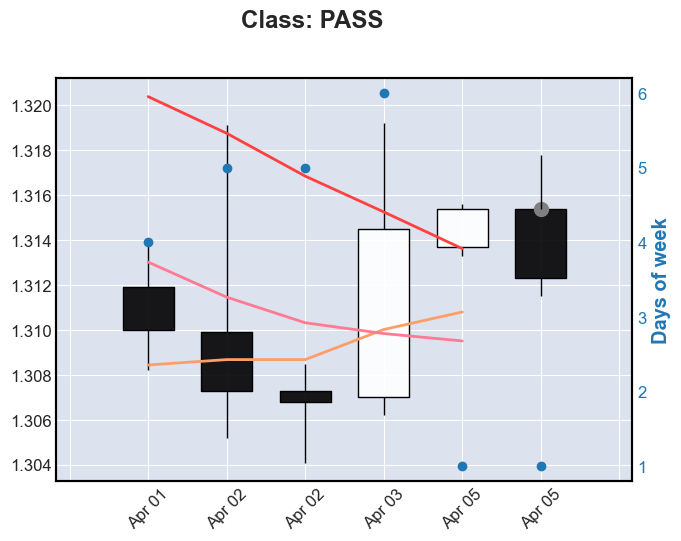

In [378]:
# Печать случайной комбинации
idx = np.random.choice(len(data))
print(idx)
print_combination(data.iloc[idx])

25159


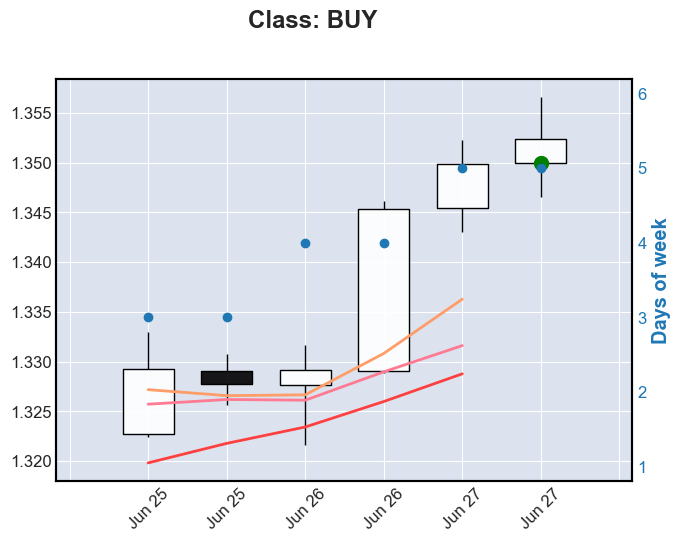

In [379]:
# Печать случайной комбинации на покупку
data_buy = data[data['class'] == 1]
idx = np.random.choice(data_buy.index)
print(idx)
print_combination(data_buy.loc[idx])

10706


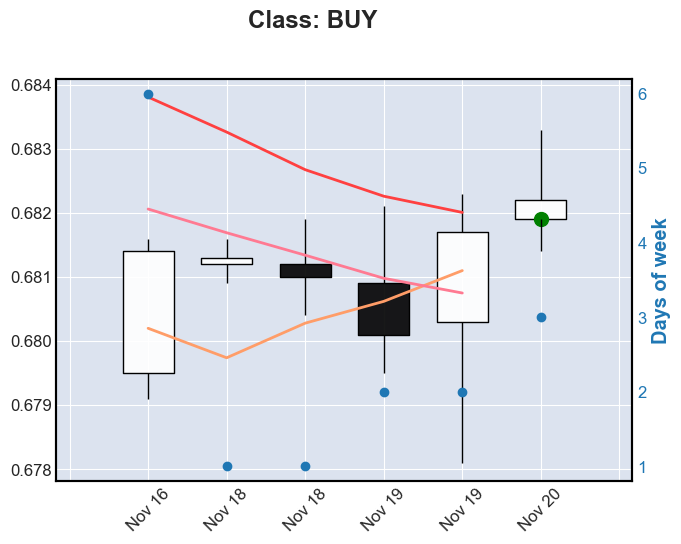

In [380]:
# Печать случайной результативной комбинации
marked_data = data[data['class'] != 0]
idx = np.random.choice(marked_data.index)
print(idx)
print_combination(marked_data.loc[idx])

#### Предобработка

In [436]:
 # Дискретизация долей
def part_sampling(p):
    # return np.where(np.isnan(p), 0, np.floor(p * 10)).astype(np.byte)     
    return np.where(np.isnan(p), 0, p)   

processed_data = data.copy()

numeric_columns = [key for key in data.columns 
                   if any([key.endswith(suffix) for suffix in NUMERIC_KEYS_SUFFIXES]) 
                      and (not key.startswith(TARGET_CANDLE_PREFIX) or key == TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX)]

# Приведение ценовых показаетелей комбинации в масштаб [0,1]
data_min = data[numeric_columns].min(axis=1)
data_max = data[numeric_columns].max(axis=1)

processed_data[numeric_columns] = processed_data[numeric_columns].sub(data_min, axis='rows').divide(data_max - data_min, axis='rows')


# Выделение дня недели
dtime_columns_fields = [(key, key.removesuffix(DATE_KEY_SUFFIX)) for key in data.columns if key.endswith(DATE_KEY_SUFFIX)]

for dtime_key, prefix in dtime_columns_fields:
    processed_data[prefix + DAY_OF_WEEK_SUFFIX] = processed_data[dtime_key].map(lambda t: datetime.fromisoformat(t).weekday())

for i in (range(1, COMBINATION_LENGTH + 1)):
    prefix = f't{i}_'
    
    data_open = data[prefix + OPEN_KEY_SUFFIX]
    data_high = data[prefix + HIGH_KEY_SUFFIX]
    data_low = data[prefix + LOW_KEY_SUFFIX]
    data_close = data[prefix + CLOSE_KEY_SUFFIX]
    data_ma5 = data[prefix + MA5_KEY_SUFFIX]
    data_ma10 = data[prefix + MA10_KEY_SUFFIX]
    data_ma15 = data[prefix + MA15_KEY_SUFFIX]

    data_size = data_high - data_low
    data_body_size = np.abs(data_close - data_open)

    # Отношения последовательных свечей
    if i > 1:
        prev_prefix = f't{i-1}_'

        # Отношение размеров свечей
        prev_data_size = data[prev_prefix + HIGH_KEY_SUFFIX] - data[prev_prefix + LOW_KEY_SUFFIX]
        ratio_size = prev_data_size / data_size
        ratio_size = np.where((np.isnan(ratio_size) | np.isinf(ratio_size)), 0, ratio_size)
        processed_data[prefix + RATIO_SIZE_KEY_SUFFIX] = ratio_size

        # Отношение размеров тел свечей 
        prev_data_body_size = np.abs(data[prev_prefix + OPEN_KEY_SUFFIX] - data[prev_prefix + CLOSE_KEY_SUFFIX])
        ratio_body_size = prev_data_body_size / data_body_size
        ratio_body_size = np.where((np.isnan(ratio_body_size) | np.isinf(ratio_body_size)), 0, ratio_body_size)
        processed_data[prefix + RATIO_BODY_SIZE_KEY_SUFFIX] = ratio_body_size

        # Отношение цен закрытия
        prev_close = data[prev_prefix + CLOSE_KEY_SUFFIX]
        processed_data[prefix + RATIO_CLOSE_KEY_SUFFIX] =  np.log(data_close / prev_close)
        
        
    # Направление свечи
    processed_data[prefix + DIRECTION_KEY_SUFFIX] = (data_close > data_open).astype(np.byte)

    # Структурные доли
    processed_data[prefix + PART_BODY_KEY_SUFFIX] = part_sampling(data_body_size / data_size)
    processed_data[prefix + PART_HEAD_KEY_SUFFIX] = part_sampling((data_high - np.max([data_close, data_open], axis=0)) / data_size)
    processed_data[prefix + PART_TAIL_KEY_SUFFIX] = part_sampling((np.min([data_close, data_open], axis=0) - data_low) / data_size)

    # Относительное позиционирование MA
    processed_data[prefix + POSITION_MA5_KEY_SUFFIX] = np.where(data_ma5 < data_low, 0,
                                                                np.where(data_ma5 < np.min([data_close, data_open], axis=0), 1,
                                                                         np.where(data_ma5 < np.max([data_close, data_open], axis=0), 2,
                                                                                  np.where(data_ma5 < data_high, 3, 4))))
    
    processed_data[prefix + POSITION_MA10_KEY_SUFFIX] = np.where(data_ma10 < data_low, 0,
                                                            np.where(data_ma10 < np.min([data_close, data_open], axis=0), 1,
                                                                        np.where(data_ma10 < np.max([data_close, data_open], axis=0), 2,
                                                                                np.where(data_ma10 < data_high, 3, 4))))
    
    processed_data[prefix + POSITION_MA15_KEY_SUFFIX] = np.where(data_ma15 < data_low, 0,
                                                            np.where(data_ma15 < np.min([data_close, data_open], axis=0), 1,
                                                                        np.where(data_ma15 < np.max([data_close, data_open], axis=0), 2,
                                                                                np.where(data_ma15 < data_high, 3, 4))))


In [437]:
# Удаление лишних столбцов
dtime_columns = [column[0] for column in dtime_columns_fields]
target_candle_columns = [column for column in processed_data.columns if column.startswith(TARGET_CANDLE_PREFIX) and column != TARGET_CANDLE_PREFIX + OPEN_KEY_SUFFIX]
droped_columns = [CURRENCY_KEY_SUFFIX] + dtime_columns + target_candle_columns  

processed_data = processed_data.drop(droped_columns, axis=1)

In [438]:
# Удаление предсказаний для понедельников из за разрыва торговых сессий
processed_data[CLASS_LABEL_KEY] = np.where(processed_data[LAST_CANDLE_PREFIX + DAY_OF_WEEK_SUFFIX] != 5, 
                                           processed_data[CLASS_LABEL_KEY], 
                                           0)

In [384]:
processed_data.head()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
0,0.724138,1.0,0.701149,0.827586,0.827586,0.827586,0.827586,0.862069,0.954023,0.413793,...,0.672727,0.517241,-0.005292,0,0.527273,0.090909,0.381818,2,2,2
1,0.903614,1.0,0.433735,0.662651,0.765060,0.765060,0.765060,0.650602,0.819277,0.349398,...,2.894737,14.500000,-0.001098,1,0.105263,0.263158,0.631579,4,4,4
2,0.855670,1.0,0.597938,0.670103,0.859107,0.859107,0.859107,0.659794,0.948454,0.567010,...,0.431818,0.052632,-0.006985,0,0.863636,0.000000,0.136364,4,4,4
3,0.846154,1.0,0.796703,0.928571,0.946429,0.946429,0.946429,0.928571,0.956044,0.653846,...,0.419048,0.730769,-0.009825,0,0.495238,0.095238,0.409524,4,4,4
4,0.971264,1.0,0.683908,0.804598,0.952874,0.952874,0.952874,0.758621,0.798851,0.689655,...,5.250000,13.000000,-0.000745,0,0.200000,0.100000,0.700000,4,4,4


In [385]:
processed_data.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
count,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,...,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000
mean,0.499171,0.698857,0.299993,0.501540,0.498614,0.495998,0.494049,0.500897,0.699673,0.302225,...,1.302134,3.093989,-0.000006,0.500122,0.439105,0.278125,0.282296,1.986667,1.974622,1.968057
std,0.266897,0.238891,0.240796,0.233774,0.250537,0.314049,0.389238,0.233928,0.220098,0.221418,...,1.263740,8.021450,0.004307,0.500003,0.249775,0.195713,0.197722,1.341918,1.636169,1.729672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039216,0.000000,...,0.000000,0.000000,-0.147223,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.280899,0.510651,0.070059,0.312653,0.301644,0.207218,0.068442,0.312183,0.530003,0.111111,...,0.641975,0.333333,-0.002079,0.000000,0.230769,0.120812,0.123077,1.000000,0.000000,0.000000
50%,0.497500,0.715472,0.280000,0.500000,0.496072,0.492140,0.487964,0.498903,0.717525,0.282928,...,1.000000,0.940000,0.000000,1.000000,0.440000,0.241379,0.246377,2.000000,2.000000,2.000000
75%,0.717194,0.926216,0.491803,0.689727,0.694199,0.784981,0.913606,0.689320,0.890984,0.473282,...,1.521127,2.538462,0.002115,1.000000,0.640625,0.404255,0.410714,3.000000,4.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982143,...,45.000000,221.250000,0.082724,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000


In [439]:
processed_data.columns

Index(['t1_open', 't1_high', 't1_low', 't1_close', 't1_ma5', 't1_ma10',
       't1_ma15', 't2_open', 't2_high', 't2_low', 't2_close', 't2_ma5',
       't2_ma10', 't2_ma15', 't3_open', 't3_high', 't3_low', 't3_close',
       't3_ma5', 't3_ma10', 't3_ma15', 't4_open', 't4_high', 't4_low',
       't4_close', 't4_ma5', 't4_ma10', 't4_ma15', 't5_open', 't5_high',
       't5_low', 't5_close', 't5_ma5', 't5_ma10', 't5_ma15', 't6_open',
       'class', 't1_dweek', 't2_dweek', 't3_dweek', 't4_dweek', 't5_dweek',
       't1_direction', 't1_part_body', 't1_head_body', 't1_tail_body',
       't1_ma5_position', 't1_ma10_position', 't1_ma15_position',
       't2_ratio_size', 't2_ratio_body_size', 't2_ratio_close', 't2_direction',
       't2_part_body', 't2_head_body', 't2_tail_body', 't2_ma5_position',
       't2_ma10_position', 't2_ma15_position', 't3_ratio_size',
       't3_ratio_body_size', 't3_ratio_close', 't3_direction', 't3_part_body',
       't3_head_body', 't3_tail_body', 't3_ma5_position',

In [138]:
processed_data.isnull().sum().sum()

np.int64(0)

##### (Неудачный эксперимент) Отбор наиболее плотных кластеров

Была идея отобрать для дальнейшего обучения только те кластеры свечей, в которых была бы выражена явная концентрация классов 1 или 2, а также исключить равносмешанные кластеры и кластеры со слабой концентрацией целевых классов.\
К ожидаемому улучшению качества модели это не привело, **в дальнейших вычислениях этот блок не используется**.

In [387]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

processed_data_without_class = processed_data.drop([CLASS_LABEL_KEY], axis=1)

scaler.fit(processed_data_without_class)
processed_data_scaled = pd.DataFrame(scaler.transform(processed_data_without_class), columns=processed_data_without_class.columns, index=processed_data_without_class.index)

processed_data_scaled.describe()

,t1_open,t1_high,t1_low,t1_close,t1_ma5,t1_ma10,t1_ma15,t2_open,t2_high,t2_low,...,t5_ratio_size,t5_ratio_body_size,t5_ratio_close,t5_direction,t5_part_body,t5_head_body,t5_tail_body,t5_ma5_position,t5_ma10_position,t5_ma15_position
count,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,...,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000,73726.000000
mean,0.499171,0.698857,0.299993,0.501540,0.498614,0.495998,0.494049,0.500897,0.687414,0.307720,...,0.028936,0.013984,0.640221,0.500122,0.439105,0.278125,0.282296,0.496667,0.493656,0.492014
std,0.266897,0.238891,0.240796,0.233774,0.250537,0.314049,0.389238,0.233928,0.229081,0.225444,...,0.028083,0.036255,0.018730,0.500003,0.249775,0.195713,0.197722,0.335480,0.409042,0.432418
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.280899,0.510651,0.070059,0.312653,0.301644,0.207218,0.068442,0.312183,0.510819,0.113131,...,0.014266,0.001507,0.631205,0.000000,0.230769,0.120812,0.123077,0.250000,0.000000,0.000000
50%,0.497500,0.715472,0.280000,0.500000,0.496072,0.492140,0.487964,0.498903,0.705996,0.288073,...,0.022222,0.004249,0.640248,1.000000,0.440000,0.241379,0.246377,0.500000,0.500000,0.500000
75%,0.717194,0.926216,0.491803,0.689727,0.694199,0.784981,0.913606,0.689320,0.886535,0.481888,...,0.033803,0.011473,0.649446,1.000000,0.640625,0.404255,0.410714,0.750000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [388]:
from sklearn.cluster import KMeans

MIN_CLUSTER_COUNT = 1
MAX_CLUSTER_COUNT = 15

# Расчет инерции
inertia = []
inertia_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT + 1)
for i in inertia_iterations:
    kmeans = KMeans(n_clusters=i, random_state=10).fit(processed_data_scaled)
    inertia_i = kmeans.inertia_
    inertia.append(inertia_i)

# Расчет переломного момента
D = []
D_iterations = range(MIN_CLUSTER_COUNT, MAX_CLUSTER_COUNT - 1)
for i in D_iterations:
    Di = (inertia[i] - inertia[i+1])/(inertia[i-1] - inertia[i])
    D.append(Di)

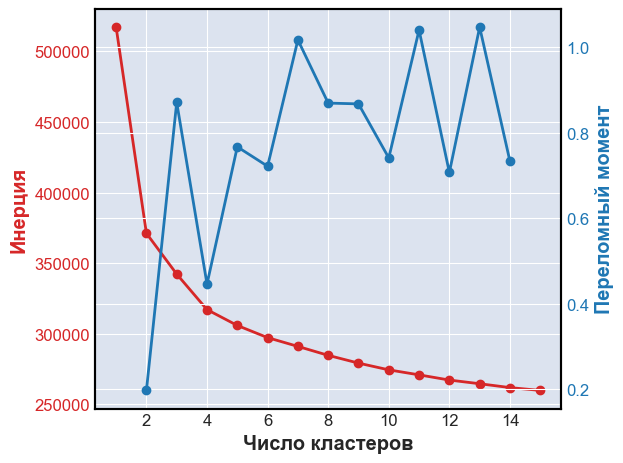

In [389]:
fig, ax1 = plt.subplots()

# Общая шкала аргумента
ax1.set_xlabel('Число кластеров')

# Совмещение графиков
ax2 = ax1.twinx()

# График инерции
color = 'tab:red'
ax1.set_ylabel('Инерция', color=color)
ax1.plot(inertia_iterations, inertia, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# График переломного момента
color = 'tab:blue'
ax2.set_ylabel('Переломный момент', color=color)
# Для переломного момента индекс для числа кластеров смещается на 1
D_num_clusters = np.array(D_iterations) + 1
ax2.plot(D_num_clusters, D, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

In [390]:
labels = KMeans(n_clusters=12, random_state=6).fit(processed_data_scaled).labels_

In [426]:
CLASS_BUY_LABEL_KEY = 'buy_class'
CLASS_SELL_LABEL_KEY = 'sell_class'

processed_data_temp = processed_data.copy()
processed_data_temp[CLASS_BUY_LABEL_KEY] = processed_data[processed_data[CLASS_LABEL_KEY] == 1][CLASS_LABEL_KEY]
processed_data_temp[CLASS_SELL_LABEL_KEY] = processed_data[processed_data[CLASS_LABEL_KEY] == 2][CLASS_LABEL_KEY]/2
processed_data_temp[[CLASS_BUY_LABEL_KEY, CLASS_SELL_LABEL_KEY]] = processed_data_temp[[CLASS_BUY_LABEL_KEY, CLASS_SELL_LABEL_KEY]].fillna(0)

processed_data_temp[CLUSTER_LABEL_KEY] = labels
processed_data_temp[[CLASS_BUY_LABEL_KEY, CLASS_SELL_LABEL_KEY, CLUSTER_LABEL_KEY]].groupby(CLUSTER_LABEL_KEY).agg(['count', 'sum', 'mean'])

buy_class                   sell_class                  
          count     sum      mean      count     sum      mean
label                                                         
0          6888  1568.0  0.227642       6888   640.0  0.092915
1          6137  1346.0  0.219325       6137   647.0  0.105426
2          7676   887.0  0.115555       7676  1464.0  0.190724
3          4592   641.0  0.139591       4592   802.0  0.174652
4          5948   633.0  0.106422       5948  1365.0  0.229489
5          5272   795.0  0.150797       5272   830.0  0.157436
6          7837  1247.0  0.159117       7837  1114.0  0.142146
7          7995  1082.0  0.135335       7995  1268.0  0.158599
8          4717  1110.0  0.235319       4717   464.0  0.098368
9          6210   898.0  0.144605       6210  1026.0  0.165217
10         5175   604.0  0.116715       5175  1121.0  0.216618
11         5279  1118.0  0.211783       5279   606.0  0.114794

In [427]:
# Исключение усредненных кластеров
good_clusters = ((processed_data[CLUSTER_LABEL_KEY] != 5) &
                 (processed_data[CLUSTER_LABEL_KEY] != 6) &  
                 (processed_data[CLUSTER_LABEL_KEY] != 7) &  
                 (processed_data[CLUSTER_LABEL_KEY] != 9))

In [428]:
processed_data[CLASS_LABEL_KEY] = np.where(good_clusters, 
                                           processed_data[CLASS_LABEL_KEY], 
                                           0)

processed_data = processed_data.drop([CLUSTER_LABEL_KEY], axis=1)

#### Моделирование

In [440]:
# Разделение на множества данных
from sklearn.metrics import precision_score, classification_report
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    processed_data.drop([CLASS_LABEL_KEY], axis=1), processed_data[CLASS_LABEL_KEY], test_size=0.3, random_state=5, shuffle=True, stratify=processed_data[CLASS_LABEL_KEY]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=5, stratify=y_test
)

print(f'Тренировочный набор: {y_train.value_counts()}')
print(f'Валидационный набор: {y_val.value_counts()}')
print(f'Тестовый набор: {y_test.value_counts()}')

Тренировочный набор: class
0    35315
1     8350
2     7943
Name: count, dtype: int64
Валидационный набор: class
0    7568
1    1789
2    1702
Name: count, dtype: int64
Тестовый набор: class
0    7567
1    1790
2    1702
Name: count, dtype: int64


#### ML

##### Ручной подбор параметров и печать кривой обучения

В качестве классификатора классическогшо ML был выбран CatBoostClassifier.

Основные параметры модели классификатора были определены вручную.\
Кривая обучения строится по вариациям количества решаюших деревьев и их глубин.

In [481]:
# Высший приоритет весов для последних свечей
def get_weight(feature: str):
    # if feature.startswith(f't{COMBINATION_LENGTH + 1}'):
    #     return 2
    # elif feature.startswith(f't{COMBINATION_LENGTH}'):
    #     return 2
    # elif feature.startswith(f't{COMBINATION_LENGTH - 1}'):
    #     return 1.5
    # elif feature.startswith('t1'):
    #     return 0.5
    # else:
    #     return 1
    return 1
    
feature_weights = {feature: get_weight(feature) for feature in processed_data.columns}
feature_weights

{'t1_open': 1,
 't1_high': 1,
 't1_low': 1,
 't1_close': 1,
 't1_ma5': 1,
 't1_ma10': 1,
 't1_ma15': 1,
 't2_open': 1,
 't2_high': 1,
 't2_low': 1,
 't2_close': 1,
 't2_ma5': 1,
 't2_ma10': 1,
 't2_ma15': 1,
 't3_open': 1,
 't3_high': 1,
 't3_low': 1,
 't3_close': 1,
 't3_ma5': 1,
 't3_ma10': 1,
 't3_ma15': 1,
 't4_open': 1,
 't4_high': 1,
 't4_low': 1,
 't4_close': 1,
 't4_ma5': 1,
 't4_ma10': 1,
 't4_ma15': 1,
 't5_open': 1,
 't5_high': 1,
 't5_low': 1,
 't5_close': 1,
 't5_ma5': 1,
 't5_ma10': 1,
 't5_ma15': 1,
 't6_open': 1,
 'class': 1,
 't1_dweek': 1,
 't2_dweek': 1,
 't3_dweek': 1,
 't4_dweek': 1,
 't5_dweek': 1,
 't1_direction': 1,
 't1_part_body': 1,
 't1_head_body': 1,
 't1_tail_body': 1,
 't1_ma5_position': 1,
 't1_ma10_position': 1,
 't1_ma15_position': 1,
 't2_ratio_size': 1,
 't2_ratio_body_size': 1,
 't2_ratio_close': 1,
 't2_direction': 1,
 't2_part_body': 1,
 't2_head_body': 1,
 't2_tail_body': 1,
 't2_ma5_position': 1,
 't2_ma10_position': 1,
 't2_ma15_position': 1,
 

In [ ]:
# Модель классификатора
from catboost import CatBoostClassifier

def fit_classifier(X_train, y_train, **kwargs):
    clf = CatBoostClassifier(
        **kwargs,
        learning_rate=0.08, 
        auto_class_weights='Balanced', 
        leaf_estimation_iterations=3,
        logging_level="Silent",
        loss_function='MultiClass',
        grow_policy='Lossguide',
        min_data_in_leaf=3,
        l2_leaf_reg=10,
        max_leaves = 22,
        feature_weights=feature_weights
        )
    clf.fit(X_train, y_train)
    return clf

# Этап обучения
def train(X_train, y_train, X_val, y_val, **kwargs):
    clf = fit_classifier(X_train=X_train, y_train=y_train, **kwargs)

    y_train_pred = clf.predict(X_train)
    q_train = precision_score(y_true=y_train, y_pred=y_train_pred, average=None)

    y_val_pred = clf.predict(X_val)
    q_val = precision_score(y_true=y_val, y_pred=y_val_pred, average=None)

    print(f'Args: {kwargs}, Val qual: {q_val}, Val pred {y_val_pred.sum()}')

    return q_train, q_val

In [503]:
# Печать кривой обучения
def print_train_curve(ax1, title, xlabel, complexity, quals_train, quals_val):
   
    # Общая шкала аргумента
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)

    # Совмещение графиков
    ax2 = ax1.twinx()

    color = 'tab:red'
    ax1.set_ylabel('Train error', color=color)
    ax1.plot(complexity, quals_train, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    color = 'tab:blue'
    ax2.set_ylabel('Val error', color=color)
    ax2.plot(complexity, quals_val, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

Args: {'n_estimators': 700, 'max_depth': 6}, Val qual: [0.99196539 0.44547739 0.44028103], Val pred 11666
Args: {'n_estimators': 800, 'max_depth': 6}, Val qual: [0.98803314 0.44578921 0.43922796], Val pred 11634
Args: {'n_estimators': 900, 'max_depth': 6}, Val qual: [0.98658127 0.44604498 0.43996861], Val pred 11603
Args: {'n_estimators': 1000, 'max_depth': 6}, Val qual: [0.98392965 0.44574037 0.44013623], Val pred 11578
Args: {'n_estimators': 1100, 'max_depth': 6}, Val qual: [0.98248263 0.44557219 0.44050433], Val pred 11555
Args: {'n_estimators': 700, 'max_depth': 7}, Val qual: [0.99257196 0.44614612 0.43953186], Val pred 11673
Args: {'n_estimators': 800, 'max_depth': 7}, Val qual: [0.9892407  0.44553459 0.43983294], Val pred 11637
Args: {'n_estimators': 900, 'max_depth': 7}, Val qual: [0.98658945 0.4461305  0.44011506], Val pred 11602
Args: {'n_estimators': 1000, 'max_depth': 7}, Val qual: [0.98509732 0.4460177  0.43972746], Val pred 11587
Args: {'n_estimators': 1100, 'max_depth': 7

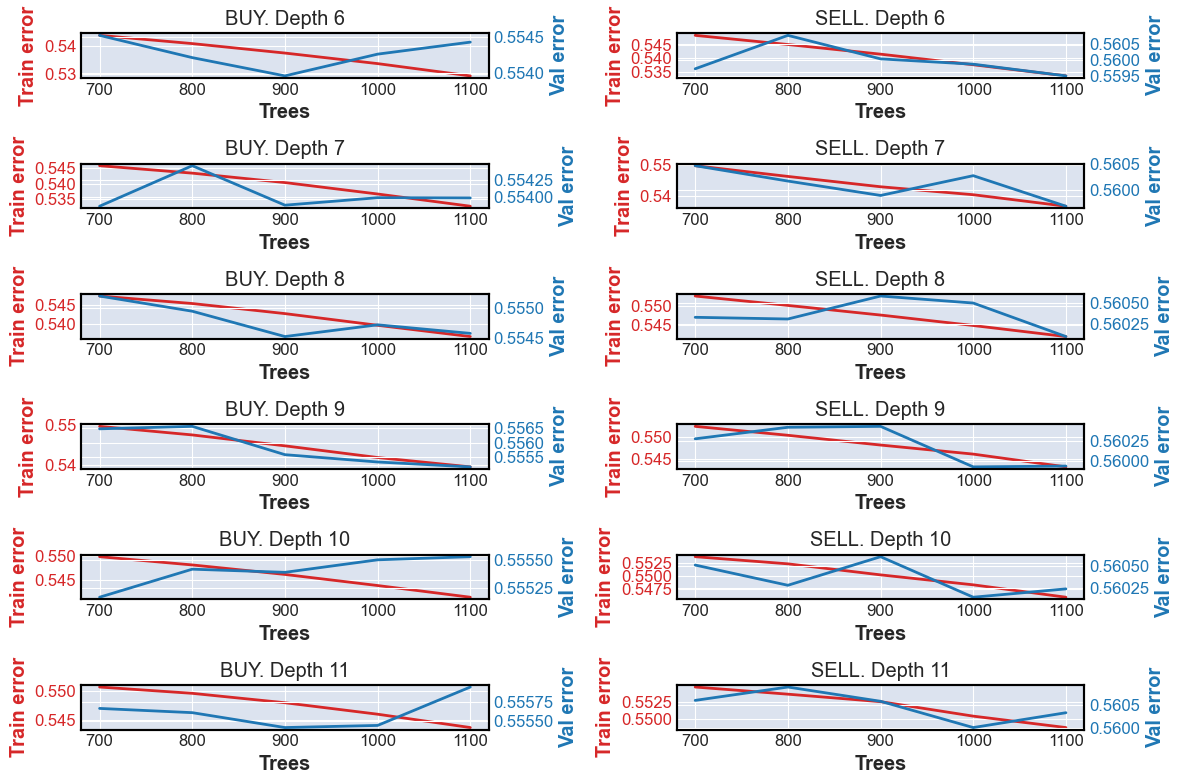

In [504]:
# Цикл обучения
axes_columns_num = 2

depth = range(6, 12)
trees = range(700, 1200, 100)

fig, axes = plt.subplots(ncols=axes_columns_num, nrows=len(depth), figsize=(12, 8))

for i, d in enumerate(depth):
    quals_train = []
    quals_val = []

    for t in trees:
        q_train, q_val = train(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, n_estimators=t, max_depth=d)

        quals_train.append(1 - q_train)
        quals_val.append(1 - q_val)

    quals_train = np.array(quals_train)
    quals_val = np.array(quals_val)
    print_train_curve(axes[i][0], f'BUY. Depth {d}', 'Trees', trees, quals_train[:,1], quals_val[:,1])
    print_train_curve(axes[i][1], f'SELL. Depth {d}', 'Trees', trees, quals_train[:,2], quals_val[:,2])

fig.tight_layout()
plt.show()

In [ ]:
# Построение классификатора от лучших гиперпараметров
clf = fit_classifier(X_train=X_train, y_train=y_train, n_estimators=1000, max_depth=9)

y_val_pred = clf.predict(X_val)
q_val = precision_score(y_true=y_val, y_pred=y_val_pred, average=None)

print(q_val)

0.4163767107399675


In [ ]:
# Проверка на тестовом множестве
y_test_pred = clf.predict(X_test)
q_test = precision_score(y_true=y_test, y_pred=y_test_pred, average=None)

print(classification_report(y_true=y_test, y_pred=y_test_pred))

[0.99223602 0.445334   0.43909422]


#### DL 

In [435]:
import torch
import torch.nn as nn
import torch.optim as optim

ModuleNotFoundError: No module named 'torch'

In [ ]:
from sklearn.preprocessing import StandardScaler

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Конвертация в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.to_numpy()).view(-1, 1)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val.to_numpy()).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.to_numpy()).view(-1, 1)

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [ ]:
# Итератор с батчеризацией
class BatchLoader():
    def __init__(self, X, y, batch_size):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.last_idx = 0
        self.dataset_size = len(X)

    def reset(self):
        self.last_idx = 0

    def __next__(self):
        if (self.last_idx == self.dataset_size):
            raise StopIteration
        
        start_idx = self.last_idx
        end_idx = start_idx + self.batch_size if start_idx + self.batch_size < self.dataset_size else self.dataset_size

        self.last_idx = end_idx
        return self.X[start_idx:end_idx], self.y[start_idx:end_idx]
    
    def __iter__(self):
        return self

    def __len__(self):
        return math.ceil(self.dataset_size / self.batch_size)

In [ ]:
# Функция для обучения модели
def train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs):
    criterion = nn.BCEWithLogitsLoss()

    train_loader = BatchLoader(X_train_tensor, y_train_tensor, batch_size)
    total_step = len(train_loader)

    # История потерь
    train_losses = []
    val_losses = []
    last_epoch = 0

    for epoch in range(num_epochs):
        need_log_epoch = epoch % (num_epochs // 5) == 0

        if need_log_epoch:
            print(f"Start of {epoch+1} Epoch:")

        train_batch_losses = []
        for i, (X, y) in enumerate(train_loader):  
            model.train()

            X = X.to(device)
            y = y.to(device)
            
            outputs = model(X)
            loss = criterion(outputs, y)

            # Потери по пакету    
            train_batch_losses.append(loss.item())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            need_log_batch = (i % (total_step // 5)) == 0
            if need_log_epoch and need_log_batch:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                    .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

        # Потеря эпохи как средняя потеря по пакету    
        train_losses.append(np.array(train_batch_losses).mean())

        # Расчет потери на валидационной выборке
        val_batch_losses = []
        with torch.no_grad():
            model.eval()
            val_loader = BatchLoader(X_val_tensor, y_val_tensor, batch_size)
            for (X, y) in val_loader:
                X = X.to(device)
                y = y.to(device)
                outputs = model(X)

                loss = criterion(outputs, y)
                # Потери по пакету    
                val_batch_losses.append(loss.item())
            
            # Потеря эпохи как средняя потеря по пакету   
            val_losses.append(np.array(val_batch_losses).mean())

        val_loader.reset()    
        train_loader.reset()
        last_epoch = epoch

        # Ранняя остановка в случае отсутствия прогресса обучения
        if epoch > num_patience_epochs:
            start_epoch = train_losses[-num_patience_epochs]
            checked_epochs = train_losses[-num_patience_epochs + 1:]
            if all([start_epoch  < checked_epoch for checked_epoch in checked_epochs]):
                break
    
    return (last_epoch + 1, train_losses, val_losses)

In [ ]:
# Визуализация потерь на обучающей и валидационной выборке
def print_losses(learning_epochs, train_losses, val_losses, title):
    epochs = range(0, learning_epochs)
    ax = plt.figure(figsize=(10,5))
    plt.title(f'Потери в процессе обучения\n{title}\nЭпохи [{learning_epochs}]')
    plt.plot(epochs, train_losses, label='Train')
    plt.plot(epochs, val_losses, label='Val')
    plt.legend()

In [ ]:
# Проверка модели
def test_model(model, X_test, y_test, bath_size, title):
    test_loader = BatchLoader(X_test, y_test, bath_size)
    y_pred = torch.FloatTensor().to(device)

    with torch.no_grad():
        model.eval()
        for (X, _) in test_loader:
            X = X.to(device)
            outputs = model(X)
            outputs = torch.round(torch.sigmoid(outputs))
            y_pred = torch.cat([y_pred, outputs], dim=0)

    y_pred_np = y_pred.cpu().view(-1).numpy()
    y_test_np = y_test.view(-1).numpy()
    

    score = f'Precision: {precision_score(y_true=y_test_np, y_pred=y_pred_np):.6f}'

    print(score)

##### FNN

In [ ]:
class Config:
    LEARNING_RATE = 0.001

    INPUT_SIZE = 88
    HIDDEN_SIZE = 200
    OUTPUT_SIZE = 1

In [ ]:
# Модель для классификации
class FunctionClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_size=10, output_size=1):
        super(FunctionClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

Start of 1 Epoch:
Epoch [1/200], Step [1/202], Loss: 0.6470
Epoch [1/200], Step [41/202], Loss: 0.2581
Epoch [1/200], Step [81/202], Loss: 0.1741
Epoch [1/200], Step [121/202], Loss: 0.1940
Epoch [1/200], Step [161/202], Loss: 0.1319
Epoch [1/200], Step [201/202], Loss: 0.1209
Start of 41 Epoch:
Epoch [41/200], Step [1/202], Loss: 0.0899
Epoch [41/200], Step [41/202], Loss: 0.0846
Epoch [41/200], Step [81/202], Loss: 0.1109
Epoch [41/200], Step [121/202], Loss: 0.0911
Epoch [41/200], Step [161/202], Loss: 0.0642
Epoch [41/200], Step [201/202], Loss: 0.0652
Start of 81 Epoch:
Epoch [81/200], Step [1/202], Loss: 0.0522
Epoch [81/200], Step [41/202], Loss: 0.0531
Epoch [81/200], Step [81/202], Loss: 0.0702
Epoch [81/200], Step [121/202], Loss: 0.0441
Epoch [81/200], Step [161/202], Loss: 0.0254
Epoch [81/200], Step [201/202], Loss: 0.0459
Start of 121 Epoch:
Epoch [121/200], Step [1/202], Loss: 0.0235
Epoch [121/200], Step [41/202], Loss: 0.0280
Epoch [121/200], Step [81/202], Loss: 0.037

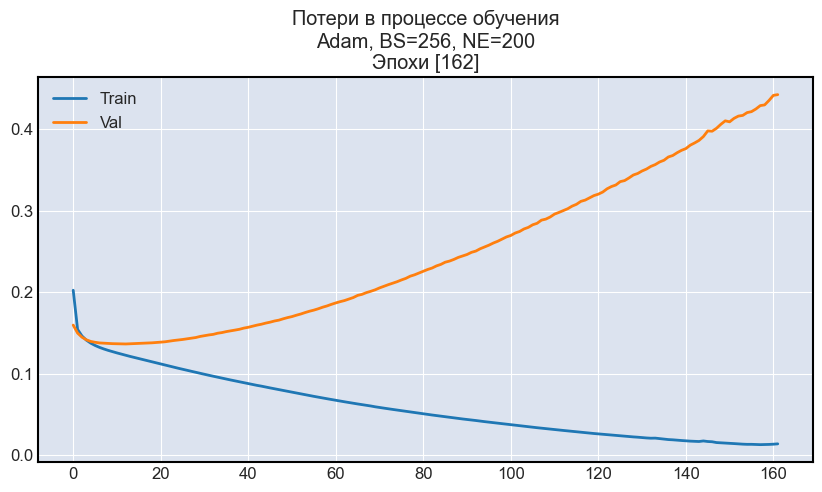

In [ ]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = FunctionClassifier(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'Adam, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_val_tensor, y_val, batch_size, title="Функция\n" + model_description)

In [ ]:
test_model(model, X_test_tensor, y_test, batch_size, title="Функция\n" + model_description)

Precision: 0.474251


#####  CNN

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_features, num_classes=3):
        super(CNNModel, self).__init__()
        
        # Первый слой свертки: извлекает локальные паттерны (фигуры свечей)
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        # Второй слой свертки: извлекает более глобальные зависимости (последовательность паттернов)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        
        # Pooling: уменьшаем размерность, оставляя только самые важные признаки
        self.pool = nn.AdaptiveAvgPool1d(1) # Сжимает последовательность до размера 1
        
        # Полносвязный слой для классификации
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = x.view(-1, 88, 1)
        # x shape: (batch_size, num_features, seq_length)
        
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        
        x = self.conv3(x)
        x = self.relu3(x)
        
        # Global Average Pooling
        x = self.pool(x) # shape: (batch, 64, 1)
        x = torch.flatten(x, 1) # shape: (batch, 64)
        
        x = self.fc(x)
        return x

In [ ]:
from torchsummary import summary

cnn_model = CNNModel(num_features=Config.INPUT_SIZE, num_classes=Config.OUTPUT_SIZE)
print(cnn_model)

# example_batch = next(enumerate(train_loader))[1][0]
# print('Batch example size: ', example_batch.shape)

# print('Summary:')
# example_x = example_batch[0]
# summary(cnn_model, example_x.shape, device='cpu')

CNNModel(
  (conv1): Conv1d(88, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (conv3): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Start of 1 Epoch:
Epoch [1/200], Step [1/202], Loss: 0.6808
Epoch [1/200], Step [41/202], Loss: 0.2606
Epoch [1/200], Step [81/202], Loss: 0.1520
Epoch [1/200], Step [121/202], Loss: 0.1714
Epoch [1/200], Step [161/202], Loss: 0.1259
Epoch [1/200], Step [201/202], Loss: 0.1069
Start of 41 Epoch:
Epoch [41/200], Step [1/202], Loss: 0.1139
Epoch [41/200], Step [41/202], Loss: 0.1308
Epoch [41/200], Step [81/202], Loss: 0.1079
Epoch [41/200], Step [121/202], Loss: 0.1127
Epoch [41/200], Step [161/202], Loss: 0.0833
Epoch [41/200], Step [201/202], Loss: 0.0915
Precision: 0.443609


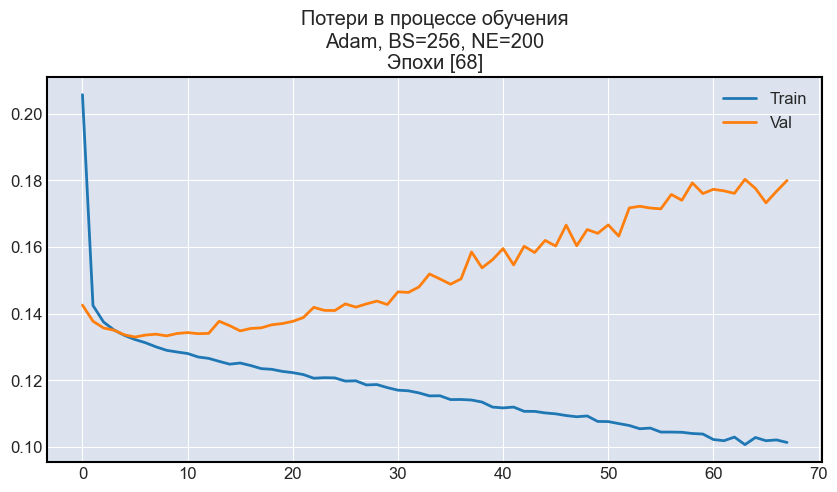

In [ ]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = CNNModel(num_features=Config.INPUT_SIZE, num_classes=Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'Adam, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_val, y_val, batch_size, title="Функция\n" + model_description)

In [ ]:
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Precision: 0.458599
